# River Change Analysis

This notebook analyzes river layers in `stat_analysis/data`.

It follows:

1. Inventory all river files.
2. Plot every river map in the notebook.
3. Compute river length statistics.
4. Plot river length / survival-style graphs.
5. Compare consecutive maps river-by-river.
6. Save outputs if `SAVE_OUTPUTS = True`.

Output structure when saving is enabled:

```text
stat_analysis/output/river_analysis_refactored/
├── inventory/
├── length_analysis/
└── pairwise_change/
    ├── tables/
    └── figures/
```

## 1. Setup

In [2]:
from pathlib import Path
import re
import unicodedata

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [4]:
REPO_ROOT = Path("../..")

DATA_DIR = REPO_ROOT / "stat_analysis" / "data"
if not DATA_DIR.exists():
    DATA_DIR = Path("../stat_analysis/data")

OUTPUT_ROOT = REPO_ROOT / "stat_analysis" / "output" / "river_analysis_refactored"
if not OUTPUT_ROOT.parent.exists():
    OUTPUT_ROOT = Path("../stat_analysis/output/river_analysis_refactored")

TARGET_EPSG = 2056

SAVE_OUTPUTS = True

# Pairwise comparison parameters
TOLERANCE_M = 50
MIN_FRAGMENT_LENGTH_M = 20

MAP_ORDER = {
    "melotte": 1721,
    "berney": 1831,
    "renove": 1888,
    "1937": 1937,
    "1959": 1959,
    "contemporain": 2021,
}

MAP_LABELS = {
    "melotte": "Melotte (1721)",
    "berney": "Berney (1831)",
    "renove": "Rénové (1888)",
    "1937": "1937",
    "1959": "1959",
    "contemporain": "Contemporary (2021)",
}

RIVER_COLORS = {
    "base": "#8E8E93",
    "stable": "#34C759",
    "lost": "#FF9F0A",
    "new": "#007AFF",
}

In [5]:
print("DATA_DIR:", DATA_DIR, DATA_DIR.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("SAVE_OUTPUTS:", SAVE_OUTPUTS)

DATA_DIR: ../../stat_analysis/data True
OUTPUT_ROOT: ../../stat_analysis/output/river_analysis_refactored
SAVE_OUTPUTS: True


## 2. Helper functions

In [6]:
def normalize_text(value):
    if not isinstance(value, str):
        return ""
    value = value.lower().strip()
    return "".join(
        c for c in unicodedata.normalize("NFD", value)
        if unicodedata.category(c) != "Mn"
    )


def sort_key_for_map(map_key):
    if map_key in MAP_ORDER:
        return MAP_ORDER[map_key]
    if str(map_key).isdigit():
        return int(map_key)
    return 9999


def label_for_map(map_key):
    return MAP_LABELS.get(map_key, str(map_key))


def infer_map_key(filename):
    lower = normalize_text(filename)

    for key in MAP_ORDER:
        if key in lower:
            return key

    match = re.search(r"\d{4}", lower)
    if match:
        return match.group()

    return None


def is_river_file(path):
    lower = normalize_text(path.name)
    return (
        path.suffix.lower() in {".gpkg"}
        and ("river" in lower or "rivers" in lower or "riviere" in lower)
    )


def normalize_river_name(value):
    name = normalize_text(value)

    mapping = {
        "la vuachere": "vuachere",
        "vuachere": "vuachere",
        "vuachere+riolet": "vuachere",
        "le flon": "flon",
        "flon": "flon",
        "la louve": "louve",
        "louve": "louve",
        "le petit flon": "petit flon",
        "petitflon": "petit flon",
        "petit flon": "petit flon",
        "riolet": "riolet",
        "boveresses": "boveresses",
        "": "unknown",
        "none": "unknown",
    }

    return mapping.get(name, name)


def find_name_column(gdf):
    candidates = ["clean_name", "name", "Name_1", "nom", "river_name", "riviere"]
    lower_cols = {c.lower(): c for c in gdf.columns}

    for c in candidates:
        if c.lower() in lower_cols:
            return lower_cols[c.lower()]

    return None


def load_river_file(path):
    gdf = gpd.read_file(path)

    if gdf.crs is None:
        raise ValueError(f"Missing CRS: {path}")

    gdf = gdf.to_crs(epsg=TARGET_EPSG)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    gdf["geometry"] = gdf.geometry.make_valid()

    name_col = find_name_column(gdf)

    if name_col is None:
        gdf["clean_name"] = "unknown"
    else:
        gdf["clean_name"] = gdf[name_col].apply(normalize_river_name)

    gdf["length_m"] = gdf.geometry.length

    return gdf


def is_save_table(df, path):
    if SAVE_OUTPUTS:
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)
        print("Saved:", path)


def is_savefig(path):
    if SAVE_OUTPUTS:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=200, bbox_inches="tight")
        print("Saved:", path)


def get_output_dirs():
    dirs = {
        "inventory": OUTPUT_ROOT / "inventory",
        "length_tables": OUTPUT_ROOT / "length_analysis" / "tables",
        "length_figures": OUTPUT_ROOT / "length_analysis" / "figures",
        "pairwise_tables": OUTPUT_ROOT / "pairwise_change" / "tables",
        "pairwise_figures": OUTPUT_ROOT / "pairwise_change" / "figures",
    }

    if SAVE_OUTPUTS:
        for d in dirs.values():
            d.mkdir(parents=True, exist_ok=True)

    return dirs


OUT = get_output_dirs()

## 3. Inventory of river files

In [7]:
river_files = sorted([p for p in DATA_DIR.glob("*") if is_river_file(p)])

inventory_rows = []

for path in river_files:
    map_key = infer_map_key(path.name)
    gdf_raw = gpd.read_file(path)

    inventory_rows.append({
        "file": path.name,
        "map_key": map_key,
        "map_label": label_for_map(map_key),
        "rows": len(gdf_raw),
        "crs": str(gdf_raw.crs),
        "geometry_types": ", ".join(gdf_raw.geom_type.value_counts().index.astype(str)),
        "columns": ", ".join(gdf_raw.columns.astype(str)),
    })

river_inventory = pd.DataFrame(inventory_rows).sort_values(
    "map_key",
    key=lambda s: s.map(sort_key_for_map),
)

display(river_inventory)

is_save_table(river_inventory, OUT["inventory"] / "river_file_inventory.csv")

,file,map_key,map_label,rows,crs,geometry_types,columns
4,melotte_rivers.gpkg,melotte,Melotte (1721),25,EPSG:2056,MultiLineString,"id, Name, Length, geometry"
2,berney_rivers.gpkg,berney,Berney (1831),41,EPSG:2056,MultiLineString,"id, name, length, geometry"
5,renove_river.gpkg,renove,Rénové (1888),35,EPSG:2056,MultiLineString,"id, length, name, geometry"
0,1937_rivers.gpkg,1937,1937,9,EPSG:21781,MultiLineString,"id, name, length, geometry"
1,1959_rivers.gpkg,1959,1959,15,EPSG:2056,MultiLineString,"id, name, Name_1, length, geometry"
3,contemporain_rivers.gpkg,contemporain,Contemporary (2021),24,EPSG:4326,MultiLineString,"osm_id, name, type, width, length, geometry"


Saved: ../../stat_analysis/output/river_analysis_refactored/inventory/river_file_inventory.csv


## 4. Load and clean river layers

In [8]:
river_layers = {}

for path in river_files:
    map_key = infer_map_key(path.name)
    if not map_key:
        print("Skipping, no map key:", path.name)
        continue

    gdf = load_river_file(path)
    gdf["map_key"] = map_key
    gdf["map_label"] = label_for_map(map_key)
    gdf["source_file"] = path.name

    river_layers[map_key] = gdf

print("Loaded river layers:")
for map_key in sorted(river_layers.keys(), key=sort_key_for_map):
    gdf = river_layers[map_key]
    print(map_key, label_for_map(map_key), gdf.shape, sorted(gdf["clean_name"].dropna().unique()))

Loaded river layers:
melotte Melotte (1721) (25, 9) ['flon', 'inconnu', 'le rionzi', 'louve', 'petit flon', 'vuachere']
berney Berney (1831) (41, 9) ['boveresses', 'flon', 'galicien', 'inconnu', 'louve', 'vuachere']
renove Rénové (1888) (35, 9) ['boveresses', 'flon', 'louve', 'unknown', 'vuachere']
1937 1937 (9, 9) ['flon', 'louve', 'unknown', 'vuachere']
1959 1959 (15, 10) ['flon', 'louve', 'petit flon', 'vuachere']
contemporain Contemporary (2021) (24, 11) ['flon', 'le rionzi', 'louve', 'petit flon', 'unknown', 'vuachere']


## 5. Plot every river layer in the notebook


Melotte (1721)


,clean_name,segment_count,length_m
0,flon,11,4029.273445
5,vuachere,5,3369.572677
3,louve,5,2292.549628
1,inconnu,2,909.247016
4,petit flon,1,17.449372
2,le rionzi,1,12.491815


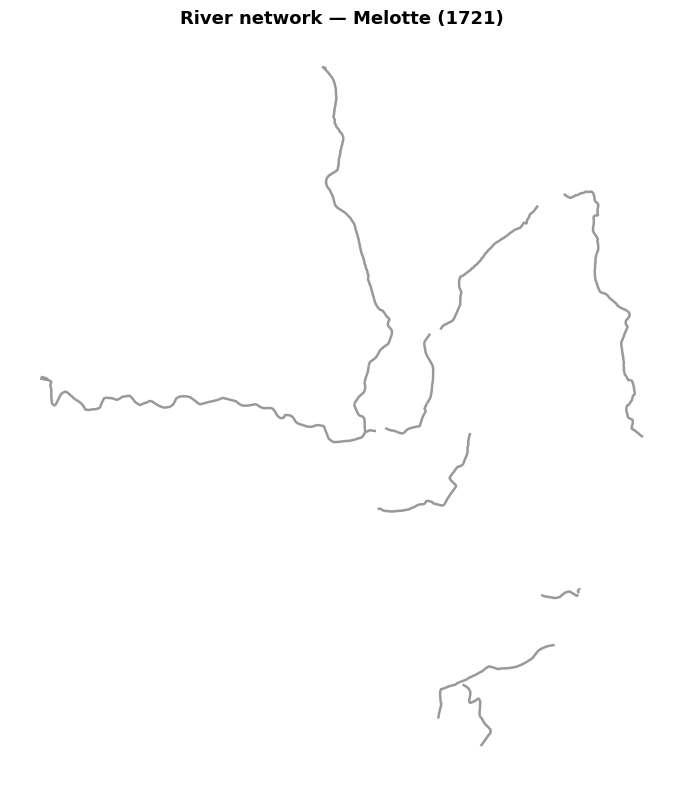


Berney (1831)


,clean_name,segment_count,length_m
1,flon,18,5898.082648
5,vuachere,6,3313.157020
4,louve,12,2068.630337
3,inconnu,3,1096.532481
0,boveresses,1,764.760876
2,galicien,1,28.136455


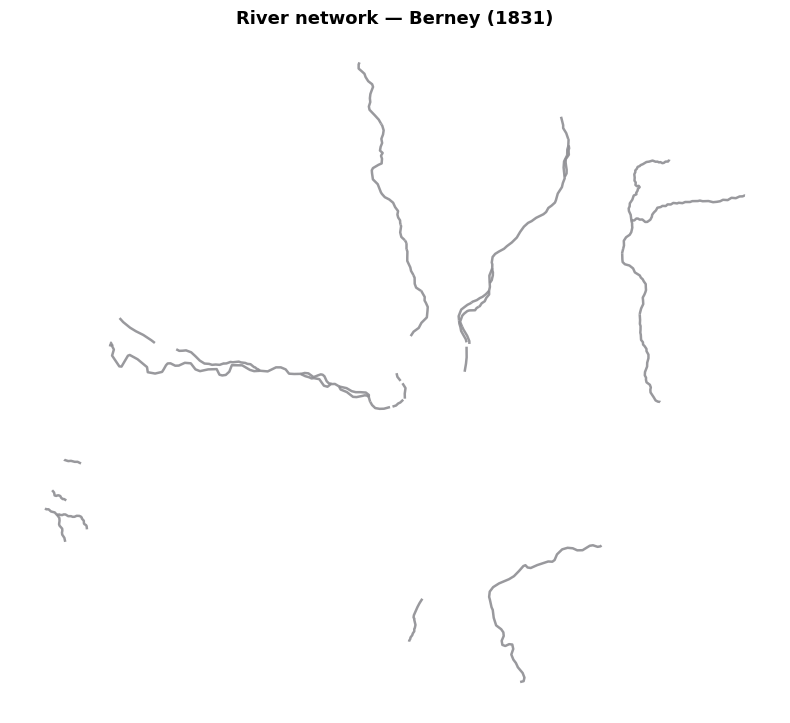


Rénové (1888)


,clean_name,segment_count,length_m
1,flon,16,5491.141052
4,vuachere,5,3371.608810
3,unknown,8,2129.313140
2,louve,5,1501.066701
0,boveresses,1,767.172249


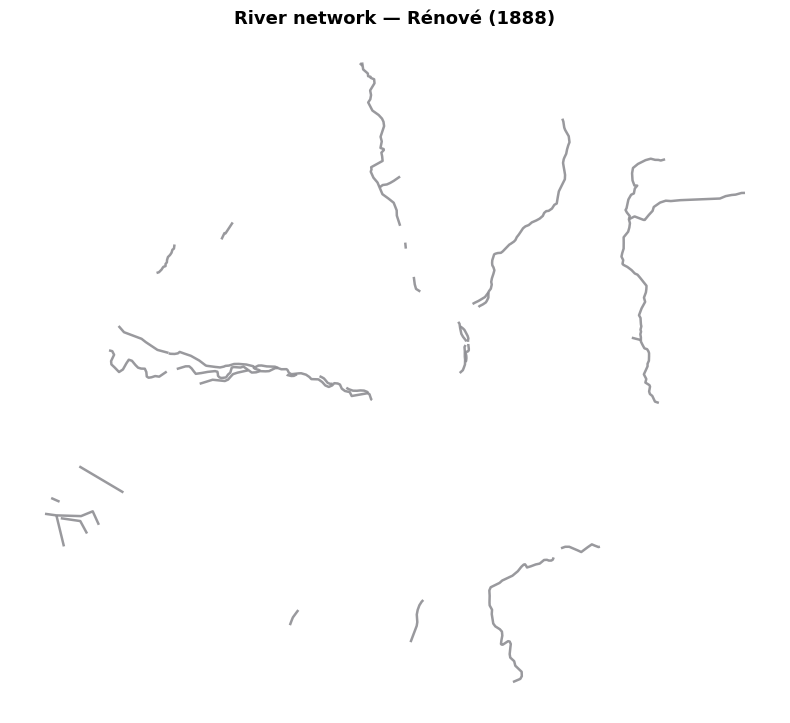


1937


,clean_name,segment_count,length_m
3,vuachere,3,1862.883981
1,louve,2,1252.870023
0,flon,2,1040.083558
2,unknown,2,1022.766261


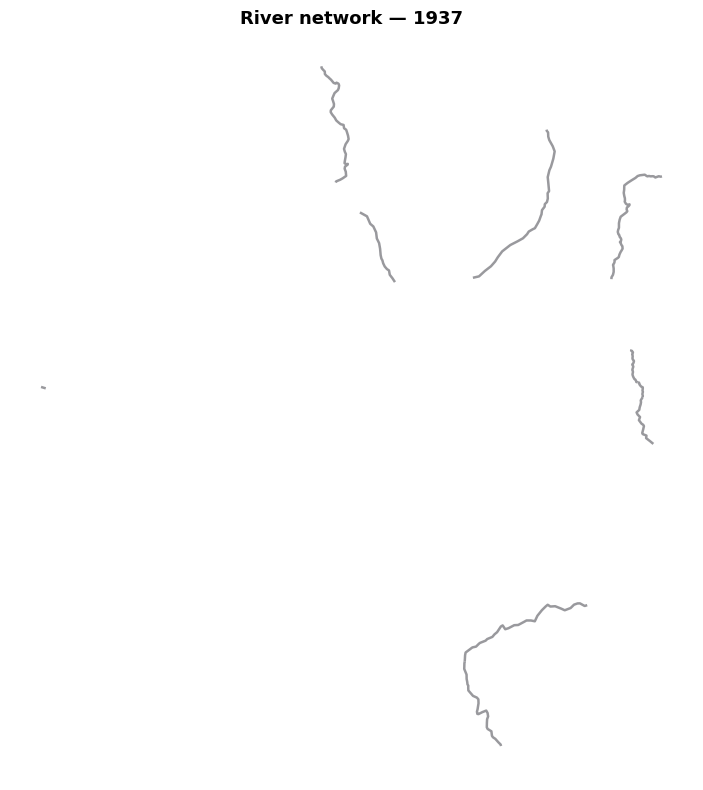


1959


,clean_name,segment_count,length_m
3,vuachere,11,2755.831550
1,louve,1,446.104586
0,flon,2,104.496923
2,petit flon,1,9.567145


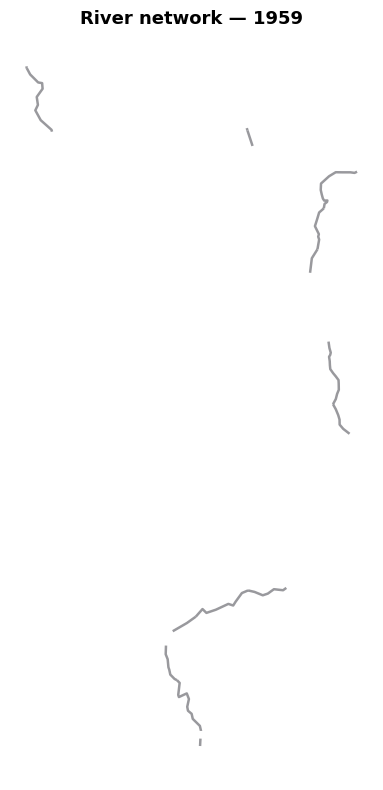


Contemporary (2021)


,clean_name,segment_count,length_m
5,vuachere,16,2793.366665
2,louve,2,338.872504
0,flon,2,115.820150
4,unknown,2,29.890129
1,le rionzi,1,12.684307
3,petit flon,1,4.186240


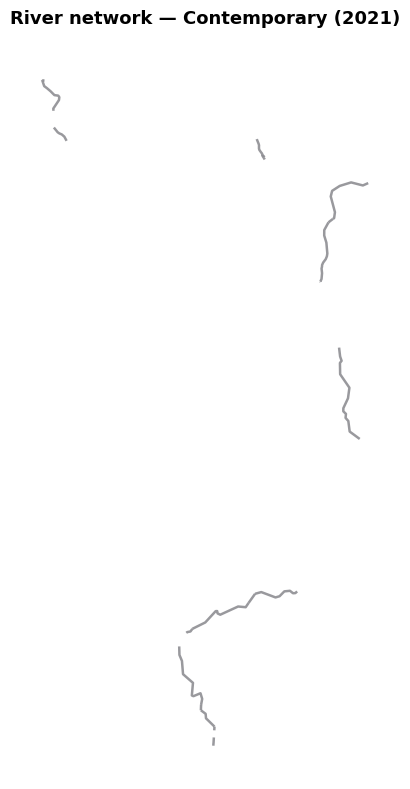

In [9]:
def plot_single_river_layer(gdf, title):
    fig, ax = plt.subplots(figsize=(8, 8))

    gdf.plot(
        ax=ax,
        color=RIVER_COLORS["base"],
        linewidth=1.8,
        alpha=0.9,
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_axis_off()
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()


for map_key in sorted(river_layers.keys(), key=sort_key_for_map):
    print("\n" + "=" * 80)
    print(label_for_map(map_key))

    gdf = river_layers[map_key]
    display(
        gdf.groupby("clean_name")
        .agg(
            segment_count=("geometry", "count"),
            length_m=("length_m", "sum"),
        )
        .reset_index()
        .sort_values("length_m", ascending=False)
    )

    plot_single_river_layer(gdf, f"River network — {label_for_map(map_key)}")

## 6. River length analysis

In [10]:
river_lengths = []

for map_key, gdf in river_layers.items():
    grouped = (
        gdf.groupby("clean_name", as_index=False)
        .agg(
            segment_count=("geometry", "count"),
            length_m=("length_m", "sum"),
        )
    )

    grouped["map_key"] = map_key
    grouped["map_label"] = label_for_map(map_key)
    grouped["sort_key"] = sort_key_for_map(map_key)

    river_lengths.append(grouped)

river_lengths_df = pd.concat(river_lengths, ignore_index=True)
river_lengths_df = river_lengths_df[river_lengths_df["clean_name"] != "unknown"].copy()
river_lengths_df = river_lengths_df.sort_values(["sort_key", "clean_name"])

display(river_lengths_df)

is_save_table(river_lengths_df, OUT["length_tables"] / "river_lengths_by_map.csv")

,clean_name,segment_count,length_m,map_key,map_label,sort_key
20,flon,11,4029.273445,melotte,Melotte (1721),1721
21,inconnu,2,909.247016,melotte,Melotte (1721),1721
22,le rionzi,1,12.491815,melotte,Melotte (1721),1721
23,louve,5,2292.549628,melotte,Melotte (1721),1721
24,petit flon,1,17.449372,melotte,Melotte (1721),1721
25,vuachere,5,3369.572677,melotte,Melotte (1721),1721
8,boveresses,1,764.760876,berney,Berney (1831),1831
9,flon,18,5898.082648,berney,Berney (1831),1831
10,galicien,1,28.136455,berney,Berney (1831),1831
11,inconnu,3,1096.532481,berney,Berney (1831),1831


Saved: ../../stat_analysis/output/river_analysis_refactored/length_analysis/tables/river_lengths_by_map.csv


In [11]:
total_lengths = (
    river_lengths_df.groupby(["map_key", "map_label", "sort_key"], as_index=False)
    .agg(total_length_m=("length_m", "sum"))
    .sort_values("sort_key")
)

display(total_lengths)

is_save_table(total_lengths, OUT["length_tables"] / "total_river_length_by_map.csv")

,map_key,map_label,sort_key,total_length_m
4,melotte,Melotte (1721),1721,10630.583952
2,berney,Berney (1831),1831,13169.299816
5,renove,Rénové (1888),1888,11130.988813
0,1937,1937,1937,4155.837562
1,1959,1959,1959,3316.000205
3,contemporain,Contemporary (2021),2021,3264.929867


Saved: ../../stat_analysis/output/river_analysis_refactored/length_analysis/tables/total_river_length_by_map.csv


## 7. Plot total river length over time

Saved: ../../stat_analysis/output/river_analysis_refactored/length_analysis/figures/total_river_length_over_time.png


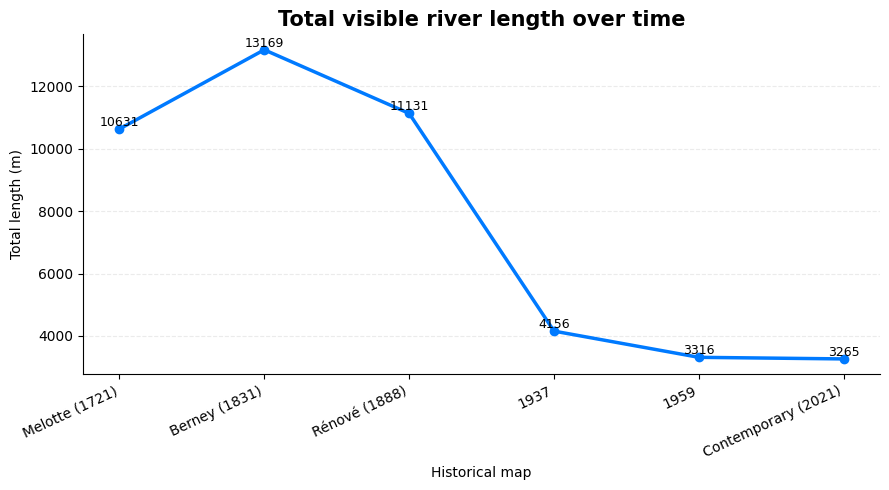

In [12]:
def plot_total_length(total_lengths):
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        total_lengths["map_label"],
        total_lengths["total_length_m"],
        color="#007AFF",
        marker="o",
        linewidth=2.5,
    )

    ax.set_title("Total visible river length over time", fontsize=15, fontweight="bold")
    ax.set_xlabel("Historical map")
    ax.set_ylabel("Total length (m)")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for x, y in zip(total_lengths["map_label"], total_lengths["total_length_m"]):
        ax.text(x, y, f"{y:.0f}", ha="center", va="bottom", fontsize=9)

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    is_savefig(OUT["length_figures"] / "total_river_length_over_time.png")
    plt.show()


plot_total_length(total_lengths)

## 8. River survival-style plot

In [13]:
def build_survival_table(river_lengths_df):
    base_key = sorted(river_lengths_df["map_key"].unique(), key=sort_key_for_map)[0]

    baseline = (
        river_lengths_df[river_lengths_df["map_key"] == base_key]
        [["clean_name", "length_m"]]
        .rename(columns={"length_m": "baseline_length_m"})
    )

    survival = river_lengths_df.merge(baseline, on="clean_name", how="left")

    survival["survival_pct"] = np.where(
        survival["baseline_length_m"] > 0,
        np.minimum(survival["length_m"] / survival["baseline_length_m"] * 100, 100),
        np.nan,
    )

    return survival.sort_values(["clean_name", "sort_key"])


survival_df = build_survival_table(river_lengths_df)
display(survival_df)

is_save_table(survival_df, OUT["length_tables"] / "river_survival.csv")

,clean_name,segment_count,length_m,map_key,map_label,sort_key,baseline_length_m,survival_pct
6,boveresses,1,764.760876,berney,Berney (1831),1831,NaN,NaN
12,boveresses,1,767.172249,renove,Rénové (1888),1888,NaN,NaN
0,flon,11,4029.273445,melotte,Melotte (1721),1721,4029.273445,100.000000
7,flon,18,5898.082648,berney,Berney (1831),1831,4029.273445,100.000000
13,flon,16,5491.141052,renove,Rénové (1888),1888,4029.273445,100.000000
16,flon,2,1040.083558,1937,1937,1937,4029.273445,25.813179
19,flon,2,104.496923,1959,1959,1959,4029.273445,2.593443
23,flon,2,115.820150,contemporain,Contemporary (2021),2021,4029.273445,2.874467
8,galicien,1,28.136455,berney,Berney (1831),1831,NaN,NaN
1,inconnu,2,909.247016,melotte,Melotte (1721),1721,909.247016,100.000000


Saved: ../../stat_analysis/output/river_analysis_refactored/length_analysis/tables/river_survival.csv


Saved: ../../stat_analysis/output/river_analysis_refactored/length_analysis/figures/river_survival_small_multiples.png


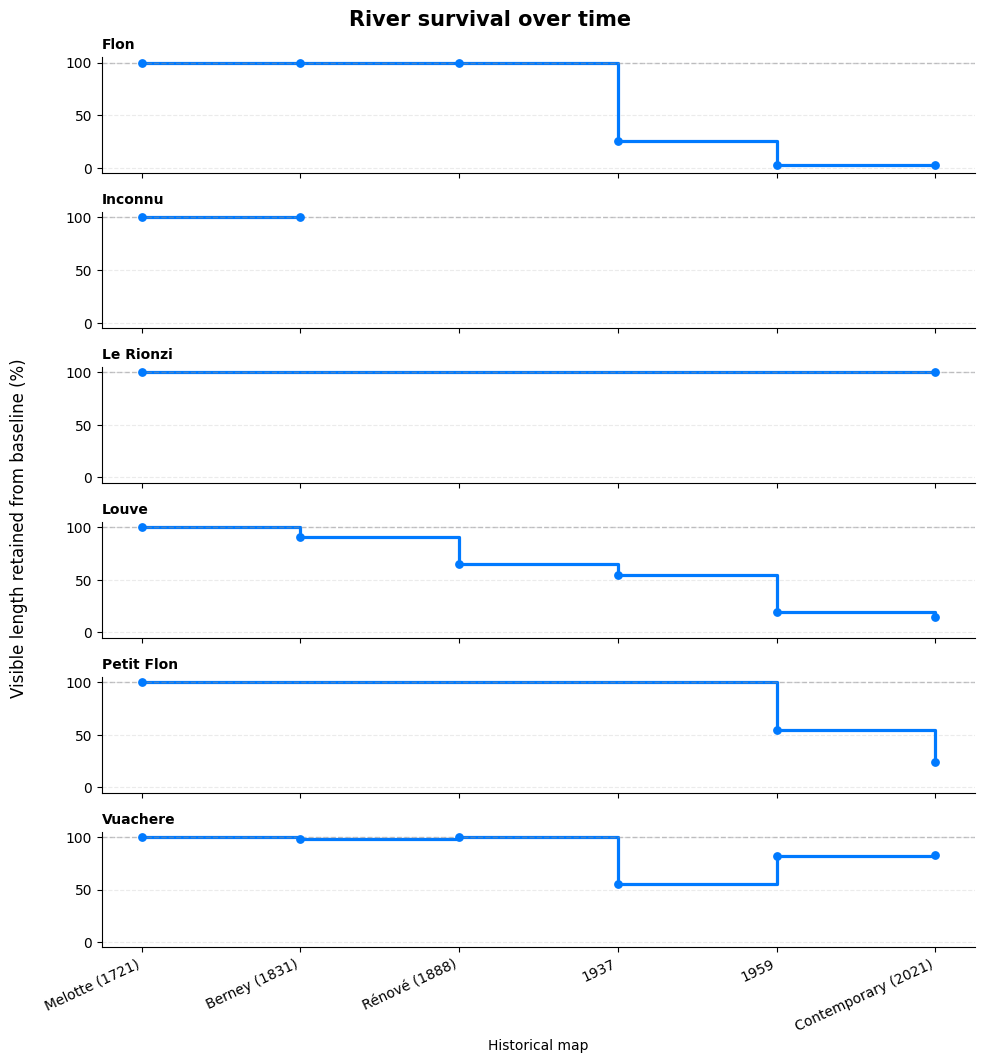

In [14]:
def plot_survival_small_multiples(survival_df):
    plot_df = survival_df.dropna(subset=["survival_pct"]).copy()
    rivers = sorted(plot_df["clean_name"].unique())

    n = len(rivers)
    fig, axes = plt.subplots(n, 1, figsize=(10, max(3, 1.8 * n)), sharex=True, sharey=True)

    if n == 1:
        axes = [axes]

    for ax, river in zip(axes, rivers):
        part = plot_df[plot_df["clean_name"] == river].sort_values("sort_key")

        ax.step(
            part["map_label"],
            part["survival_pct"],
            where="post",
            color="#007AFF",
            linewidth=2.3,
        )
        ax.scatter(
            part["map_label"],
            part["survival_pct"],
            color="#007AFF",
            s=28,
            zorder=3,
        )

        ax.set_title(river.title(), loc="left", fontsize=10, fontweight="bold")
        ax.axhline(100, color="#8E8E93", linestyle="--", linewidth=1, alpha=0.5)
        ax.set_ylim(-5, 105)
        ax.grid(axis="y", linestyle="--", alpha=0.25)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle("River survival over time", fontsize=15, fontweight="bold")
    fig.supylabel("Visible length retained from baseline (%)")
    axes[-1].set_xlabel("Historical map")

    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    is_savefig(OUT["length_figures"] / "river_survival_small_multiples.png")
    plt.show()


plot_survival_small_multiples(survival_df)

## 9. Pairwise river-by-river change analysis

In [15]:
def remove_short_fragments(geom, min_length_m=MIN_FRAGMENT_LENGTH_M):
    if geom is None or geom.is_empty:
        return geom

    parts = gpd.GeoSeries([geom], crs=f"EPSG:{TARGET_EPSG}").explode(index_parts=False)
    parts = parts[parts.length >= min_length_m]

    if parts.empty:
        return parts.union_all()

    return parts.union_all()


def compare_pair_by_river(gdf_a, gdf_b, map_a, map_b, tolerance_m=TOLERANCE_M):
    rows = []
    layers = {}

    rivers = sorted(set(gdf_a["clean_name"].dropna()) | set(gdf_b["clean_name"].dropna()))
    rivers = [r for r in rivers if r != "unknown"]

    for river in rivers:
        sub_a = gdf_a[gdf_a["clean_name"] == river]
        sub_b = gdf_b[gdf_b["clean_name"] == river]

        geom_a = sub_a.geometry.union_all() if not sub_a.empty else None
        geom_b = sub_b.geometry.union_all() if not sub_b.empty else None

        len_a = geom_a.length if geom_a is not None else 0.0
        len_b = geom_b.length if geom_b is not None else 0.0

        if geom_a is None:
            stable = None
            lost = None
            new = geom_b
        elif geom_b is None:
            stable = None
            lost = geom_a
            new = None
        else:
            buffer_a = geom_a.buffer(tolerance_m)
            buffer_b = geom_b.buffer(tolerance_m)

            stable = geom_a.intersection(buffer_b)
            lost = geom_a.difference(buffer_b)
            new = geom_b.difference(buffer_a)

        stable = remove_short_fragments(stable)
        lost = remove_short_fragments(lost)
        new = remove_short_fragments(new)

        stable_len = stable.length if stable is not None else 0.0
        lost_len = lost.length if lost is not None else 0.0
        new_len = new.length if new is not None else 0.0

        rows.append({
            "period": f"{label_for_map(map_a)} → {label_for_map(map_b)}",
            "map_start": map_a,
            "map_end": map_b,
            "river_name": river,
            "length_start_m": len_a,
            "length_end_m": len_b,
            "stable_length_m": stable_len,
            "lost_length_m": lost_len,
            "new_length_m": new_len,
            "stable_pct_of_start": stable_len / len_a * 100 if len_a > 0 else np.nan,
            "lost_pct_of_start": lost_len / len_a * 100 if len_a > 0 else np.nan,
            "tolerance_m": tolerance_m,
        })

        layers[(map_a, map_b, river)] = {
            "start": geom_a,
            "end": geom_b,
            "stable": stable,
            "lost": lost,
            "new": new,
        }

    return pd.DataFrame(rows), layers


pairwise_tables = []
pairwise_layers = {}

ordered_keys = sorted(river_layers.keys(), key=sort_key_for_map)

for map_a, map_b in zip(ordered_keys[:-1], ordered_keys[1:]):
    table, layers = compare_pair_by_river(river_layers[map_a], river_layers[map_b], map_a, map_b)
    pairwise_tables.append(table)
    pairwise_layers.update(layers)

pairwise_df = pd.concat(pairwise_tables, ignore_index=True) if pairwise_tables else pd.DataFrame()
display(pairwise_df)

is_save_table(pairwise_df, OUT["pairwise_tables"] / "pairwise_river_change_by_name.csv")

,period,map_start,map_end,river_name,length_start_m,length_end_m,stable_length_m,lost_length_m,new_length_m,stable_pct_of_start,lost_pct_of_start,tolerance_m
0,Melotte (1721) → Berney (1831),melotte,berney,boveresses,0.000000,764.760876,0.000000,0.000000,764.760876,NaN,NaN,50
1,Melotte (1721) → Berney (1831),melotte,berney,flon,4029.273445,5898.082648,3689.882869,320.518299,1337.423311,91.576879,7.954742,50
2,Melotte (1721) → Berney (1831),melotte,berney,galicien,0.000000,28.136455,0.000000,0.000000,28.136455,NaN,NaN,50
3,Melotte (1721) → Berney (1831),melotte,berney,inconnu,909.247016,1096.532481,0.000000,909.247016,1096.532481,0.000000,100.000000,50
4,Melotte (1721) → Berney (1831),melotte,berney,le rionzi,12.491815,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50
5,Melotte (1721) → Berney (1831),melotte,berney,louve,2292.549628,2068.630337,2034.586454,244.907278,147.979787,88.747761,10.682747,50
6,Melotte (1721) → Berney (1831),melotte,berney,petit flon,17.449372,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50
7,Melotte (1721) → Berney (1831),melotte,berney,vuachere,3369.572677,3313.157020,2043.843465,1314.124971,1398.137095,60.655865,38.999752,50
8,Berney (1831) → Rénové (1888),berney,renove,boveresses,764.760876,767.172249,764.760876,0.000000,0.000000,100.000000,0.000000,50
9,Berney (1831) → Rénové (1888),berney,renove,flon,5898.082648,5491.141052,5492.622396,369.360656,196.407635,93.125558,6.262385,50


Saved: ../../stat_analysis/output/river_analysis_refactored/pairwise_change/tables/pairwise_river_change_by_name.csv


## 10. Pairwise summary graphs

In [16]:
pairwise_summary = (
    pairwise_df.groupby(["period", "map_start", "map_end"], as_index=False)
    .agg(
        stable_length_m=("stable_length_m", "sum"),
        lost_length_m=("lost_length_m", "sum"),
        new_length_m=("new_length_m", "sum"),
    )
)

pairwise_summary["sort_key"] = pairwise_summary["map_start"].map(sort_key_for_map)
pairwise_summary = pairwise_summary.sort_values("sort_key")

display(pairwise_summary)

is_save_table(pairwise_summary, OUT["pairwise_tables"] / "pairwise_change_summary.csv")

,period,map_start,map_end,stable_length_m,lost_length_m,new_length_m,sort_key
3,Melotte (1721) → Berney (1831),melotte,berney,7768.312789,2788.797563,4772.970005,1721
2,Berney (1831) → Rénové (1888),berney,renove,11095.876507,1996.002306,288.883894,1831
4,Rénové (1888) → 1937,renove,1937,3892.601877,7238.386936,443.697631,1888
0,1937 → 1959,1937,1959,2557.223801,1598.613761,966.555352,1937
1,1959 → Contemporary (2021),1959,contemporain,3292.519325,0.000000,0.000000,1959


Saved: ../../stat_analysis/output/river_analysis_refactored/pairwise_change/tables/pairwise_change_summary.csv


Saved: ../../stat_analysis/output/river_analysis_refactored/pairwise_change/figures/pairwise_change_summary.png


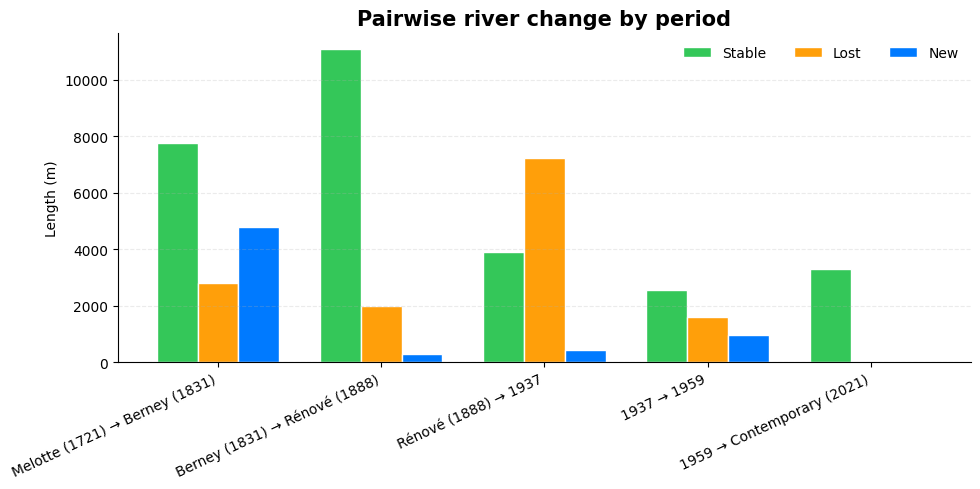

In [17]:
def plot_pairwise_summary(pairwise_summary):
    fig, ax = plt.subplots(figsize=(10, 5))

    x = np.arange(len(pairwise_summary))
    width = 0.25

    ax.bar(
        x - width,
        pairwise_summary["stable_length_m"],
        width,
        label="Stable",
        color=RIVER_COLORS["stable"],
        edgecolor="white",
        linewidth=1,
    )
    ax.bar(
        x,
        pairwise_summary["lost_length_m"],
        width,
        label="Lost",
        color=RIVER_COLORS["lost"],
        edgecolor="white",
        linewidth=1,
    )
    ax.bar(
        x + width,
        pairwise_summary["new_length_m"],
        width,
        label="New",
        color=RIVER_COLORS["new"],
        edgecolor="white",
        linewidth=1,
    )

    ax.set_title("Pairwise river change by period", fontsize=15, fontweight="bold")
    ax.set_ylabel("Length (m)")
    ax.set_xticks(x)
    ax.set_xticklabels(pairwise_summary["period"], rotation=25, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.legend(frameon=False, ncol=3)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    is_savefig(OUT["pairwise_figures"] / "pairwise_change_summary.png")
    plt.show()


plot_pairwise_summary(pairwise_summary)

## 11. Pairwise change maps

Saved: ../../stat_analysis/output/river_analysis_refactored/pairwise_change/figures/01_river_change_melotte_to_berney.png


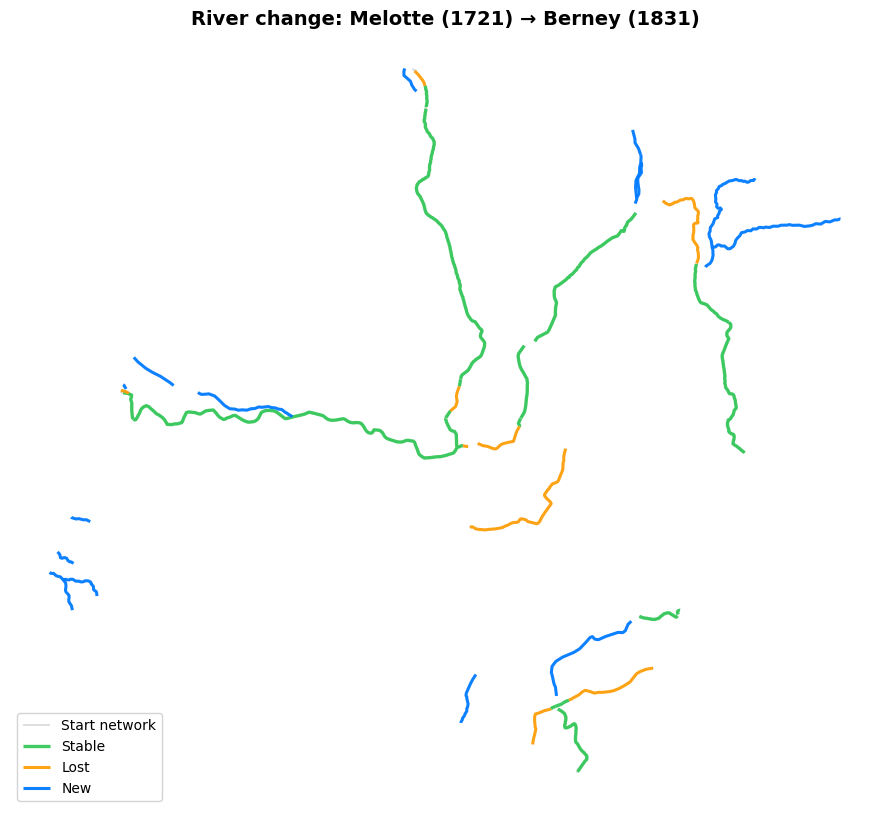

Saved: ../../stat_analysis/output/river_analysis_refactored/pairwise_change/figures/02_river_change_berney_to_renove.png


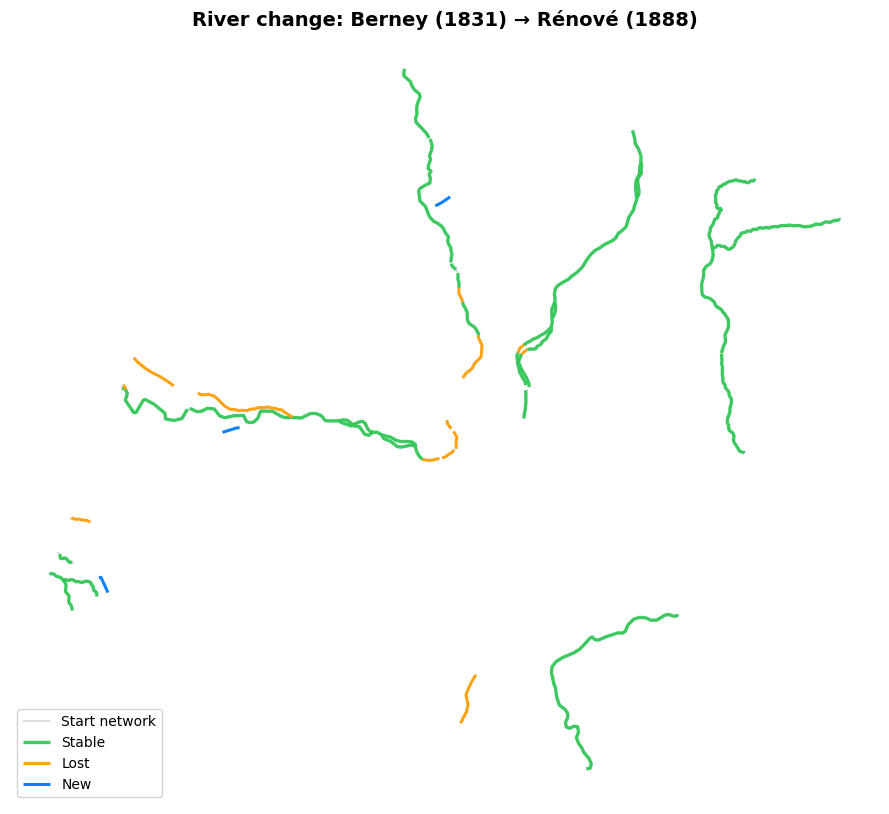

Saved: ../../stat_analysis/output/river_analysis_refactored/pairwise_change/figures/03_river_change_renove_to_1937.png


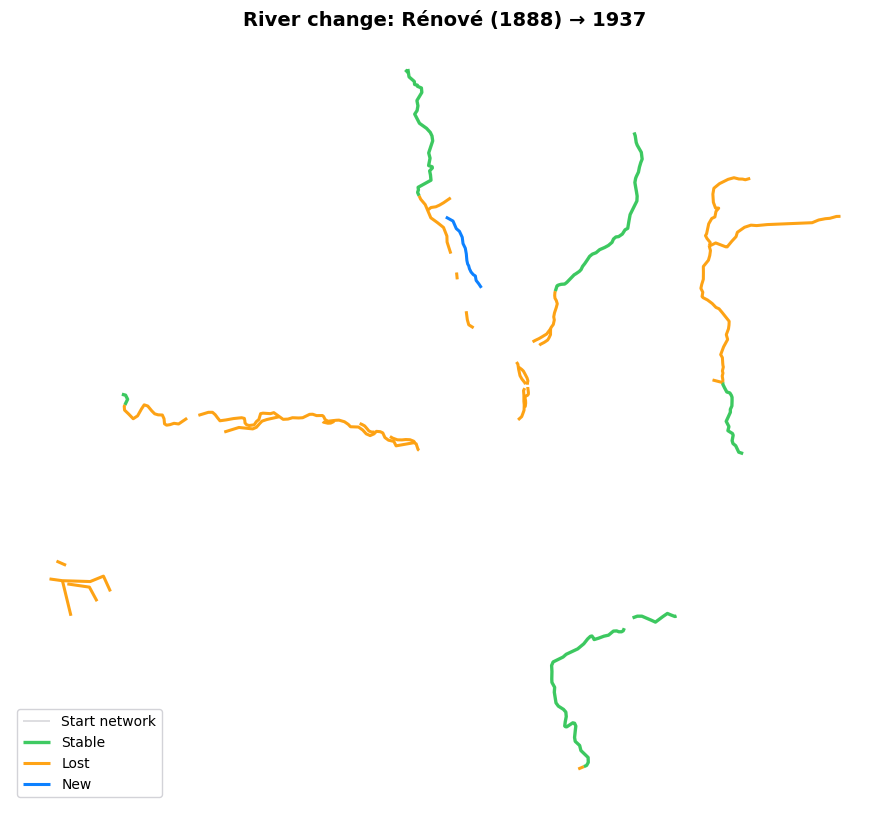

Saved: ../../stat_analysis/output/river_analysis_refactored/pairwise_change/figures/04_river_change_1937_to_1959.png


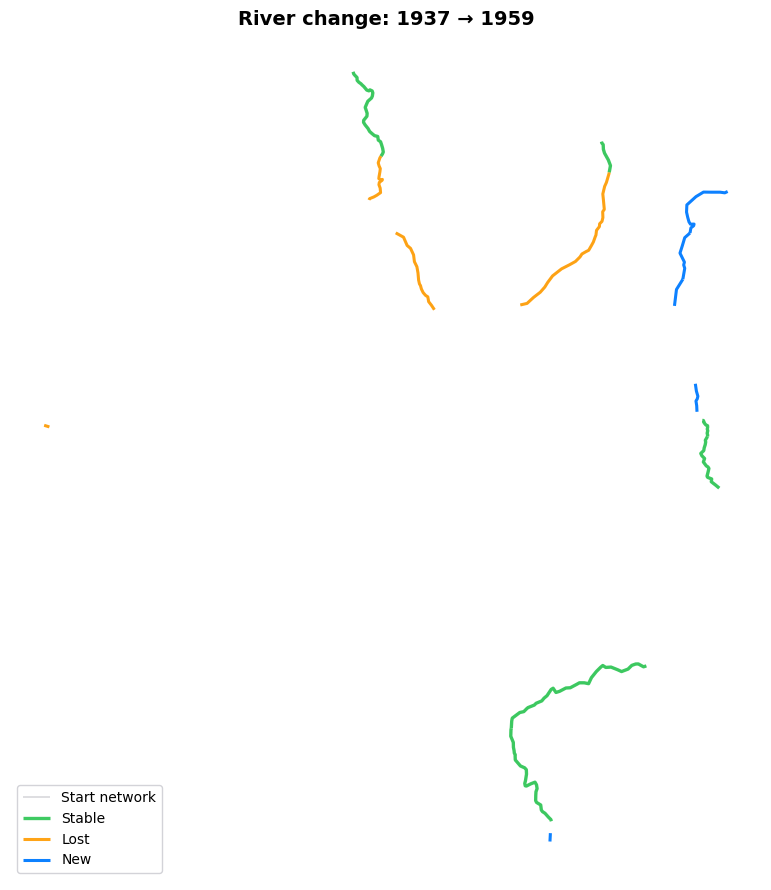

Saved: ../../stat_analysis/output/river_analysis_refactored/pairwise_change/figures/05_river_change_1959_to_contemporain.png


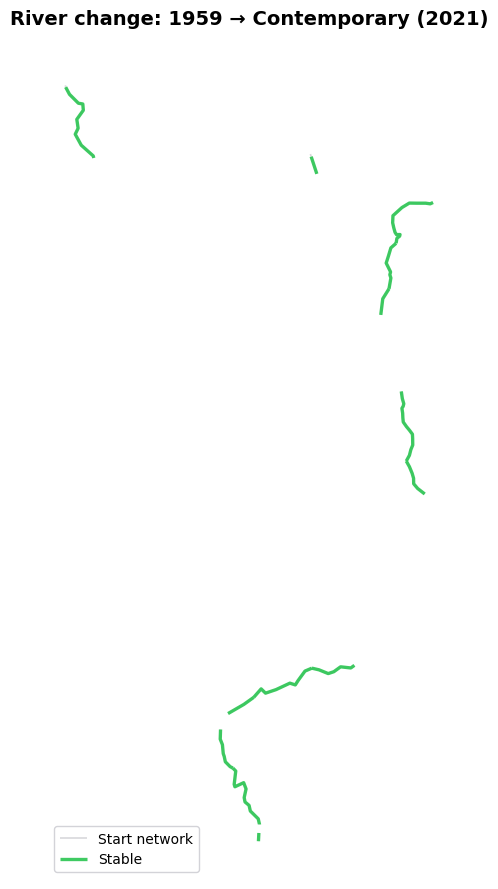

In [18]:
def plot_geom(ax, geom, color, label, linewidth=2.0, alpha=1.0, zorder=1):
    if geom is None or geom.is_empty:
        return

    gpd.GeoSeries([geom], crs=f"EPSG:{TARGET_EPSG}").plot(
        ax=ax,
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        label=label,
        zorder=zorder,
    )


def merge_layers_for_period(pairwise_layers, map_a, map_b):
    merged = {"start": [], "stable": [], "lost": [], "new": []}

    for (a, b, river), parts in pairwise_layers.items():
        if a != map_a or b != map_b:
            continue

        for key in merged:
            geom = parts.get(key)
            if geom is not None and not geom.is_empty:
                merged[key].append(geom)

    out = {}
    for key, values in merged.items():
        out[key] = (
            gpd.GeoSeries(values, crs=f"EPSG:{TARGET_EPSG}").union_all()
            if values else None
        )

    return out


def plot_pairwise_change_map(map_a, map_b, parts, out_path=None):
    fig, ax = plt.subplots(figsize=(9, 9))

    plot_geom(ax, parts["start"], "#C7C7CC", "Start network", linewidth=1.2, alpha=0.7, zorder=1)
    plot_geom(ax, parts["stable"], RIVER_COLORS["stable"], "Stable", linewidth=2.4, alpha=0.95, zorder=3)
    plot_geom(ax, parts["lost"], RIVER_COLORS["lost"], "Lost", linewidth=2.2, alpha=0.95, zorder=4)
    plot_geom(ax, parts["new"], RIVER_COLORS["new"], "New", linewidth=2.2, alpha=0.95, zorder=5)

    ax.set_title(
        f"River change: {label_for_map(map_a)} → {label_for_map(map_b)}",
        fontsize=14,
        fontweight="bold",
    )

    ax.set_axis_off()
    ax.set_aspect("equal")

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))

    ax.legend(
        unique.values(),
        unique.keys(),
        loc="lower left",
        frameon=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="#D1D1D6",
    )

    plt.tight_layout()

    if out_path is not None:
        is_savefig(out_path)

    plt.show()


for idx, (map_a, map_b) in enumerate(zip(ordered_keys[:-1], ordered_keys[1:]), start=1):
    parts = merge_layers_for_period(pairwise_layers, map_a, map_b)

    plot_pairwise_change_map(
        map_a,
        map_b,
        parts,
        OUT["pairwise_figures"] / f"{idx:02d}_river_change_{map_a}_to_{map_b}.png",
    )

## 12. How to save outputs

At the top of the notebook, change:

```python
SAVE_OUTPUTS = False
```

to:

```python
SAVE_OUTPUTS = True
```

Then rerun the notebook.

Saved outputs will appear under:

```text
stat_analysis/output/river_analysis_refactored/
```